In [1]:
#%pip install --upgrade open_clip_torch huggingface_hub
#%pip install seaborn

In [2]:
import pandas as pd

labels = pd.read_csv('../data/private/labels.csv')

labels['disease_clean'] = labels['disease']
labels['disease_clean'] = labels['disease_clean'].str.replace('-', ' ', regex=False)
labels['disease_clean'] = labels['disease_clean'].str.title()
labels['disease_clean'] = labels['disease_clean'].str.replace('(Nm)', '(NM)', regex=False)

labels.head()

,Unnamed: 0,DDI_ID,DDI_file,skin_tone,malignant,disease,disease_clean
0,2,3,000003.png,56,True,mycosis-fungoides,Mycosis Fungoides
1,3,4,000004.png,56,True,squamous-cell-carcinoma-in-situ,Squamous Cell Carcinoma In Situ
2,4,5,000005.png,12,True,basal-cell-carcinoma,Basal Cell Carcinoma
3,15,16,000016.png,56,True,mycosis-fungoides,Mycosis Fungoides
4,16,17,000017.png,56,True,mycosis-fungoides,Mycosis Fungoides


In [3]:
# Referenced: https://www.geeksforgeeks.org/python/image-datasets-dataloaders-and-transforms-in-pytorch/
import os
from PIL import Image
import torch

class DermImageDataset(torch.utils.data.Dataset):
    def __init__(self, dir, dataframe, col, transform=None):
        self.df = dataframe
        self.data_dir = dir
        self.transform = transform
        self.col = col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        fname = row["DDI_file"]
        label = row[self.col]

        image_path = os.path.join(self.data_dir, fname)
        image = Image.open(image_path).convert("RGB")
        text = f"a dermatology clinical image of {label}"

        if self.transform:
            image = self.transform(image) #CLIP preprocessing: resize, center crop to 224x224, & normalize

        return image, text, fname

In [4]:
import open_clip

device = "mps" if torch.backends.mps.is_available() else "cpu"
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32-quickgelu", pretrained="openai")
model = model.to(device).eval()

## Step 1 — Embed every image

Goal: turn every image in the dataset into a 512-d CLIP vector. Once we have these embeddings, finding visually similar images becomes a single matrix multiply.

You'll need:
- A `DataLoader` over `DermImageDataset(..., transform=preprocess)` so each batch comes out as a `[B, 3, 224, 224]` tensor.
- A loop that runs each batch through `model.encode_image`, L2-normalizes the result, and accumulates into one `[N, 512]` tensor.
- `with torch.no_grad():` to skip gradient tracking (faster, less memory).
- `shuffle=False` so row `i` of your embeddings always corresponds to the same filename.

In [5]:
from torch.utils.data import DataLoader

images_for_embed = DermImageDataset(
    dir='../data/private/images',
    dataframe=labels,
    col="disease_clean",
    transform=preprocess,
)

loader = DataLoader(images_for_embed, batch_size=32, shuffle=False)

all_embeddings, all_fnames, all_labels = [], [], []

for batch_images, batch_labels, batch_fnames in loader:
    batch_images = batch_images.to(device)
    with torch.no_grad():
        emb = model.encode_image(batch_images)
        emb = emb/emb.norm(dim=-1, keepdim=True) #Apply L2 Normalization
    all_embeddings.append(emb.cpu())
    all_fnames.extend(batch_fnames)
    all_labels.extend(batch_labels)

all_embeddings = torch.cat(all_embeddings, dim=0)

print(f"Embedded {all_embeddings.shape[0]} images, each {all_embeddings.shape[1]}-d")

Embedded 363 images, each 512-d


## Step 2 — Find nearest neighbors for a query image

Goal: given one query image, find the `k` images most visually similar to it.

You'll need:
- A query embedding (one image through the same encode + normalize pipeline).
- A cosine similarity score against every reference embedding. Since both are L2-normalized, this is just `query @ all_embeddings.T`.
- `torch.topk` to pull out the `k` highest-scoring indices.

In [6]:
query_idx = 0
query_emb = all_embeddings[query_idx]
similarities = query_emb @ all_embeddings.T

k = 5
top_scores, top_idx = torch.topk(similarities, k=k+1)

print(f"QUERY: {all_fnames[query_idx]} | {all_labels[query_idx]}")
print("-" * 60)
for score, idx in zip(top_scores[1:], top_idx[1:]):
    i = idx.item()
    print(f"{all_fnames[i]} | {all_labels[i]} | sim={score:.3f}")

QUERY: 000003.png | a dermatology clinical image of Mycosis Fungoides
------------------------------------------------------------
000256.png | a dermatology clinical image of Verruca Vulgaris | sim=0.909
000115.png | a dermatology clinical image of Verruca Vulgaris | sim=0.902
000206.png | a dermatology clinical image of Melanocytic Nevi | sim=0.896
000432.png | a dermatology clinical image of Seborrheic Keratosis | sim=0.894
000068.png | a dermatology clinical image of Mycosis Fungoides | sim=0.894


In [7]:
# claude-assisted: add FST display to investigate skin-tone bias in retrieval
FST_LABEL = {12: "I-II", 34: "III-IV", 56: "V-VI"}
fst_by_fname = dict(zip(labels['DDI_file'], labels['skin_tone']))

q_fname = all_fnames[query_idx]
print(f"QUERY: {q_fname} | FST {FST_LABEL[fst_by_fname[q_fname]]} | {all_labels[query_idx]}")
print("-" * 70)
for score, idx in zip(top_scores[1:], top_idx[1:]):
    i = idx.item()
    fname = all_fnames[i]
    fst = FST_LABEL[fst_by_fname[fname]]
    print(f"{fname} | FST {fst} | {all_labels[i]} | sim={score:.3f}")

QUERY: 000003.png | FST V-VI | a dermatology clinical image of Mycosis Fungoides
----------------------------------------------------------------------
000256.png | FST I-II | a dermatology clinical image of Verruca Vulgaris | sim=0.909
000115.png | FST V-VI | a dermatology clinical image of Verruca Vulgaris | sim=0.902
000206.png | FST V-VI | a dermatology clinical image of Melanocytic Nevi | sim=0.896
000432.png | FST I-II | a dermatology clinical image of Seborrheic Keratosis | sim=0.894
000068.png | FST V-VI | a dermatology clinical image of Mycosis Fungoides | sim=0.894


## Step 3 — Visualize the results

Goal: show the query image alongside its top-k nearest neighbors, with similarity scores as titles. This is your sanity check that retrieval is doing something sensible.

You'll need:
- `plt.subplots(1, k+1, figsize=...)` for a single row of `k+1` panels (query + k neighbors).
- A way to load each neighbor's image by index — easiest is to use a `DermImageDataset` instance with `transform=None` so you get back the raw PIL image for display.

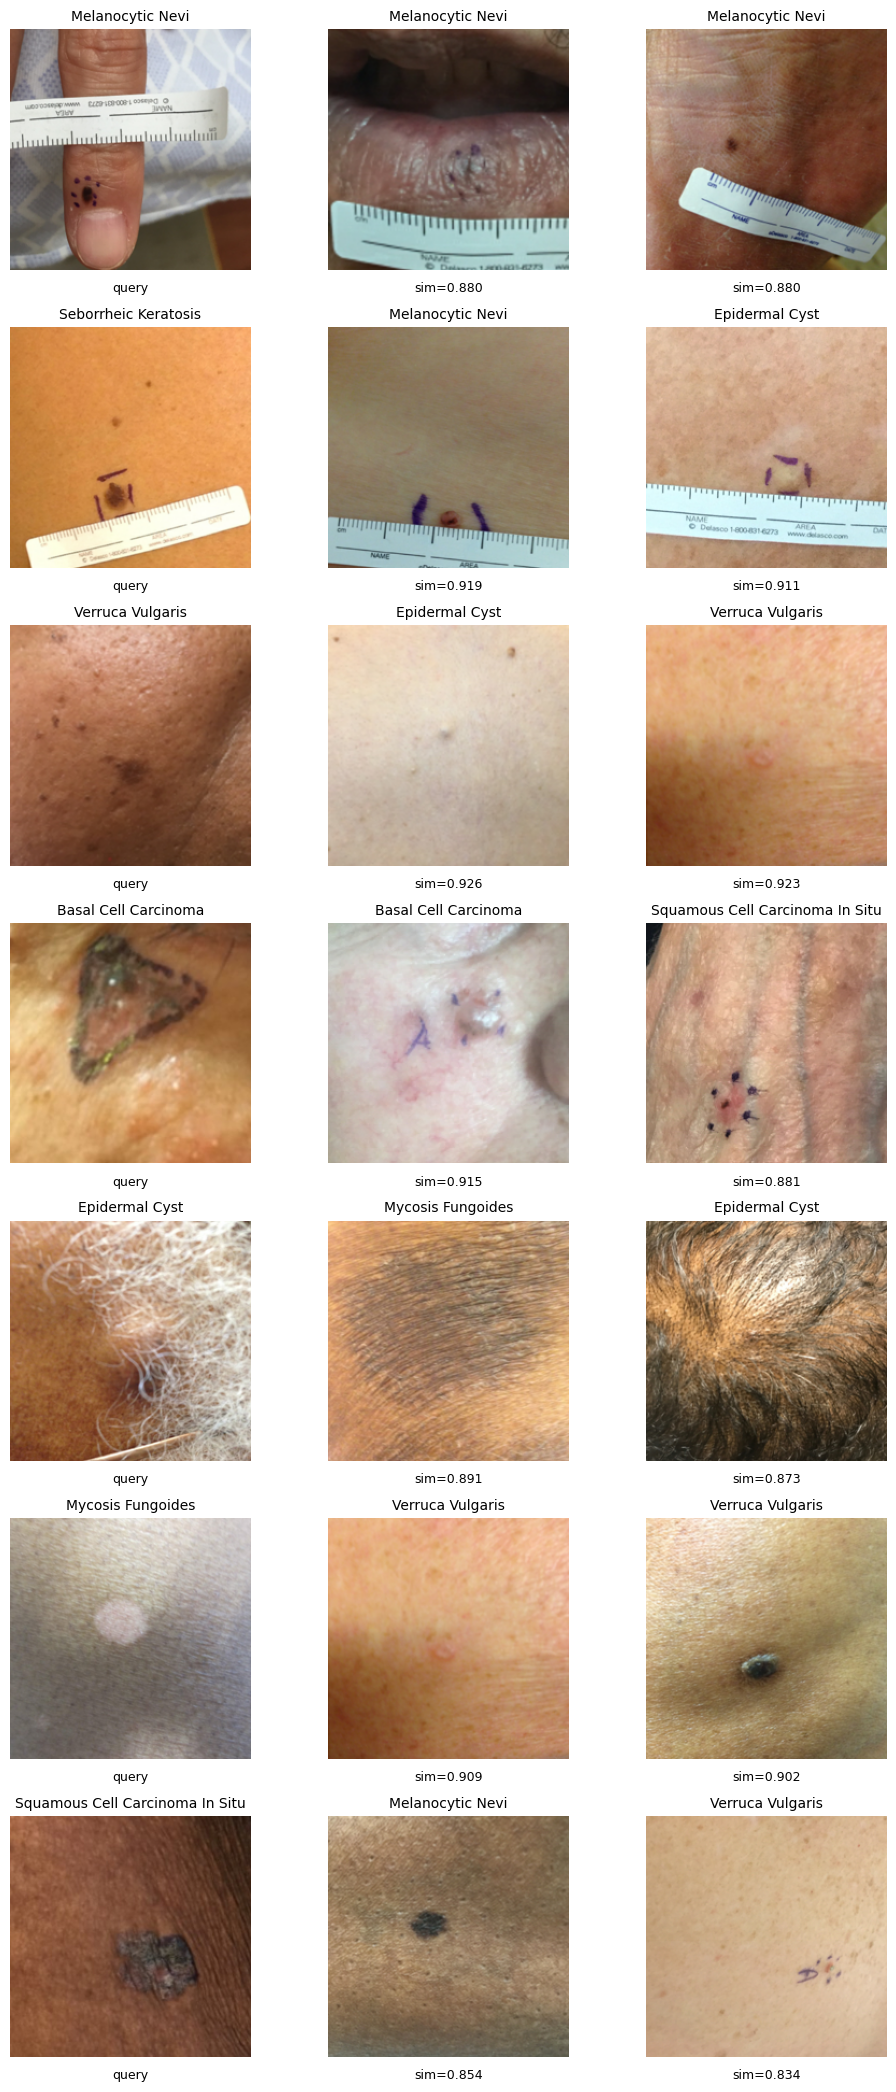

In [8]:
# claude-assisted: image-level sanity check across all 7 top conditions — 7x3 grid
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

clip_display = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
])

top_conditions = json.loads(Path('../data/public/top_conditions.json').read_text())

fig, axes = plt.subplots(len(top_conditions), 3, figsize=(10, 3 * len(top_conditions)))

for row_axes, condition in zip(axes, top_conditions):
    q_idx = labels[labels['disease_clean'] == condition].index[0]
    sims = all_embeddings[q_idx] @ all_embeddings.T
    scores, idxs = torch.topk(sims, k=3)
    for ax, idx, score in zip(row_axes, idxs, scores):
        i = idx.item()
        label = all_labels[i].replace('a dermatology clinical image of ', '')
        img = clip_display(Image.open(f"../data/private/images/{all_fnames[i]}").convert("RGB"))
        bottom = "query" if i == q_idx else f"sim={score:.3f}"
        ax.imshow(img)
        ax.set_title(label, fontsize=10)
        ax.text(0.5, -0.05, bottom, transform=ax.transAxes, ha='center', va='top', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()


## Step 4 — Aggregate visual similarity across condition pairs

The previous cells showed CLIP retrieving similar images for *one* query. Aggregating that signal across every image of each condition gives a class-level confusion picture: which conditions does the model think look alike, and which are visually distinct?

The matrix below is the mean cosine similarity between every (condition A, condition B) pair, computed from the L2-normalized CLIP embeddings of all 656 images. Higher = more visually similar. The diagonal is internal consistency — how tightly each class's images cluster in CLIP space.

Source data: `data/public/lookalike_stats.json` (produced by `scripts/03_compute_stats.py`).


In [9]:
# claude-assisted: render lookalike_stats.json as a 7x7 DataFrame
import json
from pathlib import Path
import pandas as pd

stats = json.loads(Path('../data/public/lookalike_stats.json').read_text())
df = pd.DataFrame(stats['matrix']).reindex(
    index=stats['conditions'], columns=stats['conditions']
)
df.round(3)


,Melanocytic Nevi,Seborrheic Keratosis,Verruca Vulgaris,Basal Cell Carcinoma,Epidermal Cyst,Mycosis Fungoides,Squamous Cell Carcinoma In Situ
Melanocytic Nevi,0.784,0.785,0.777,0.767,0.758,0.738,0.769
Seborrheic Keratosis,0.785,0.802,0.789,0.782,0.765,0.749,0.788
Verruca Vulgaris,0.777,0.789,0.789,0.783,0.761,0.752,0.781
Basal Cell Carcinoma,0.767,0.782,0.783,0.805,0.759,0.749,0.785
Epidermal Cyst,0.758,0.765,0.761,0.759,0.753,0.733,0.756
Mycosis Fungoides,0.738,0.749,0.752,0.749,0.733,0.776,0.745
Squamous Cell Carcinoma In Situ,0.769,0.788,0.781,0.785,0.756,0.745,0.795


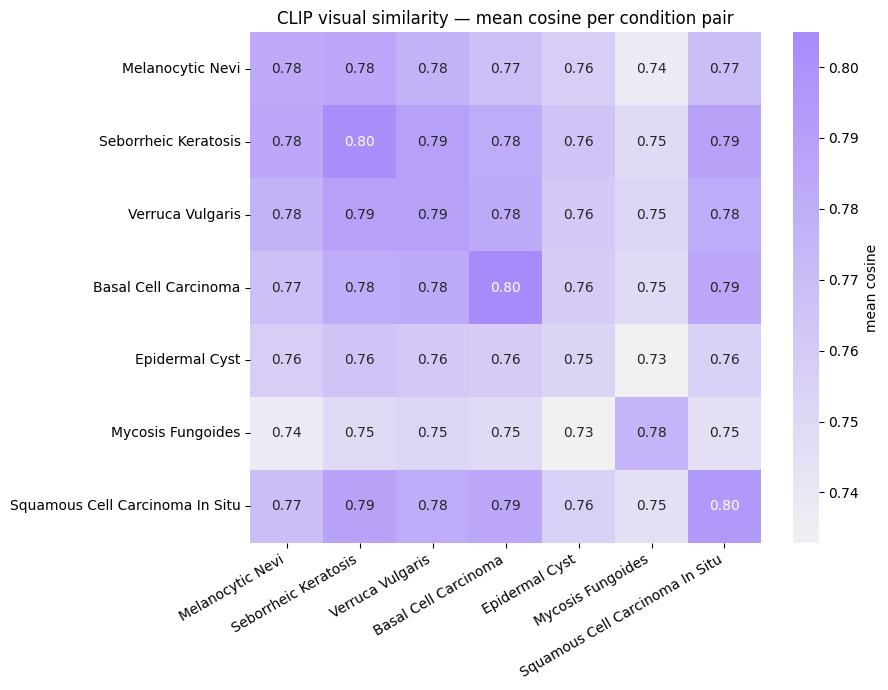

In [10]:
# claude-assisted: brand-colored heatmap, saved to assets/ for README + walkthrough
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.light_palette('#A78BFA', as_cmap=True)  # brand violet
sns.heatmap(
    df, annot=True, fmt='.2f', cmap=cmap, square=True,
    cbar_kws={'label': 'mean cosine'}, ax=ax,
)
ax.set_title('CLIP visual similarity — mean cosine per condition pair')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../assets/lookalike_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
